<a href="https://colab.research.google.com/github/shivainlabs/Machine-Learning/blob/main/Supervised%20Learning/Linear%20Regression/Copy_of_W5_Programming_withoutSol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt

This assignments has two sections:
* Linear Regression
* Kernel Regression




# Section 1:

**Linear Regression**

We will use the Boston_housing dataset for the regression problem. Run the below cell to get the following variables:
* `Training_data` = Training data matrix of shape $(n, d)$
* `labels` = label vector corresponding to the training data
* `test_data` = Test data matrix of shape $(n_1, d)$ where $n_1$ is the number of examples in test dataset.
* `test_labels` = label vector corresponding to the test data

Use this dataset for the regression problem.

In [27]:
from keras.datasets import boston_housing
Train, test = boston_housing.load_data(seed= 111)
Training_data, labels = Train[0], Train[1]
Test_data, test_labels = test[0], test[1]

## Question 1
How many examples are there in the training dataset?



In [28]:
## Enter your solution here
Training_data.shape[0]

404

## Question 2
How many examples are there in the test dataset?



In [29]:
## Enter your solution here
Test_data.shape[0]

102

## Question 3

How many features are there in the dataset?



In [30]:
## Enter your solution here
Training_data.shape
Test_data.shape[1]

13

Linear regression model for the dataset ${\mathbb{x}, y}$ is given as
$$h_w(\mathbb{x}) = w_1x^{1}+w_2x^{2}+...+w_dx^{d} =  \mathbb{x}^Tw
$$

where $x^{i}$ is the $i^{th}$ feature, $\mathbb{x}$ is the feature matrix of shape $(d, n)$ and $w = [w_1, w_2, ...w_d]^T$ is the weight vector.


Notice that above model always pass through the origin but for a given dataset, best fit model need not pass through the origin. To tackle this issue, we add an intercept $w_0$ in the model and set the corresponding featrue $x^{0}$ to $1$. That is

$$h_w(\mathbb{x}) =w_0x^{0}+ w_1x^{1}+w_2x^{2}+...+w_dx^{n} =  \mathbb{x}^Tw
$$

We call $x^{0}$ the dummy feature and set its value to 1 for each examples. Now $w$ is of shape $(d+1, 1)$ and $\mathbb{x}$ is of shape $(d+1, n)$ where the first row of $\mathbb{x}$ has entries as 1.


## Task

Add the dummy feature in the feature matrix `Training_data` and test data matrix `test_data`. We will be using this new feature matrices (after adding te dummy feature) for learning the model.

Note: As per your convenience, you can convert the shape of the training dataset to $(d, n)$.

In [31]:
## Enter your solution here
Training_data.shape
Training_data  = np.append(Training_data,np.ones((Training_data.shape[0],1)),axis=1)
Test_data = np.append(Test_data,np.ones((Test_data.shape[0],1)),axis=1)

In [32]:
X = Training_data.T

## Question 4
If the solution of optimization problem is obtained by setting the first derivative of loss function (squared loss) to zero, find the value of $w_0+w_1+...w_d$.




In [33]:
y = labels

In [34]:
## Enter your solution here
w = np.dot(np.linalg.inv(np.dot(X,X.T)),np.dot(X,y))
w.sum()

np.float64(20.52458246465715)

## Question 5
Find the average of the predictions made by the above model.



In [35]:
## Enter your solution here
yhat = np.dot(w.T,X)
yhat.mean()

np.float64(22.30915841583923)

## Question 6

Find the loss for the training data points using the above model. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [36]:
y.shape[0]

404

In [37]:
## Enter your solution here

np.sqrt(1/y.shape[0]*(np.sum((y-yhat)**2)))

np.float64(4.552387969840813)

## Question 7

Find the loss for the test data points using the above model. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [38]:
## Enter your solution here
y_test = np.dot(w,Test_data.T)
np.sqrt(1/test_labels.shape[0]*(np.sum((test_labels-y_test)**2)))

np.float64(5.327662216182647)

## Question 8
Find the weights using the gradient descent. Use a constant learning rate of $\eta = 10^{-10}$. Initialize the weight vector as zero vector and update the weights for 100 iterations. Enter the sum of all the weights.



In [39]:
w

array([-1.19191426e-01,  3.49034448e-02,  4.76183993e-02,  4.22247932e+00,
       -1.93428312e+01,  4.23451257e+00,  7.00963079e-03, -1.37028486e+00,
        3.52625213e-01, -1.32525419e-02, -1.01042893e+00,  1.06098912e-02,
       -5.00476986e-01,  3.39712899e+01])

In [40]:
## Enter your solution here
n = 1e-10 # 10**-10 (1 X 10 power -10)
w = np.zeros((X.shape[0]))
iter = 100

for i in range(iter):
  w = w - n * (2*(np.dot(np.dot(X,X.T),w)-np.dot(X,y)))
w.sum()

np.float64(0.058959061195902635)

In [41]:
w

array([-5.09455988e-05,  1.62737973e-03,  4.95579098e-04,  7.52578727e-06,
        3.62130099e-05,  5.04129247e-04,  4.03267490e-03,  3.41356839e-04,
        3.32757188e-04,  2.15186218e-02,  1.26868172e-03,  2.82816603e-02,
        4.89426249e-04,  7.40008965e-05])

## Question 9

Find the loss for the training data points if the model is learnt using the gradient descent as in question 8. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [43]:
## Enter your solution here
yhat = np.dot(w.T,X)
np.sqrt(1/y.shape[0]*(np.sum((y-yhat)**2)))

np.float64(11.137273237021954)

## Question 10

Find the loss for the test data points if the model is learnt using the gradient descent as in question 8. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [44]:
## Enter your solution here
y_test = np.dot(w,Test_data.T)
np.sqrt(1/test_labels.shape[0]*(np.sum((test_labels-y_test)**2)))

np.float64(10.964491250062142)

## Question 11
Find the weights using the stochastic gradient descent. Use a constant learning rate of $\eta = 10^{-8}$. Initialize the weight vector as zero vector and update the weights for 1000 iterations. . Take the batch size of $⌈\text{number of samples}/5⌉ $. For sampling the batch examples in $ith$ iteration, set seed at $i$. The final weight is the last updated weight. Do not take the avearge of weights updated in all the iterations. Enter the sum of all the weights.




In [68]:
## Enter your solution here
n = 1e-8
w = np.zeros((X.shape[0]))
iter = 1000
batch_size = X.shape[1]//5

for i in range(iter):
  for j in range(batch_size):
    x_tilde,y_tilde = X[:,j:j+batch_size],y[j:j+batch_size]
    w = w - n * (2*(np.dot(np.dot(x_tilde,x_tilde.T),w)-np.dot(x_tilde,y_tilde)))

w.sum()



np.float64(0.24550739229982393)

In [ ]:
"""
Iteration 0 → sample one batch → update w
Iteration 1 → sample one batch → update w
Iteration 2 → sample one batch → update w
...
Iteration 999 → sample one batch → update w

Therefore only one loop is needed.

"""

In [73]:
# correct implementation

n = 1e-8
w = np.zeros((X.shape[0]))
iter = 1000
batch_size = int(np.ceil(X.shape[1]/5))

for i in range(iter):
  # for j in range(batch_size):
  #   x_tilde,y_tilde = X[:,j:j+batch_size],y[j:j+batch_size]
  #   w = w - n * (2*(np.dot(np.dot(x_tilde,x_tilde.T),w)-np.dot(x_tilde,y_tilde)))

  np.random.seed(i)
  indices = np.random.choice(X.shape[1], batch_size, replace=False)
  print(indices)

[400 238  60 230 134 297 307 261 303 102 348 322 339 326  12 135  65 179
 317  90 259 271 142 141 159 369 190 293  15 176 140 365 362  74  37  76
 253 387 175  54 375 106 289 158   6   1 300 296  59 325 144 240 199 124
 146 100 173 200 122  52  10  26  45  78 298   4 205 194 378 341   5 381
 171 275   7  22  68  20 219  14 346]
[360  62 374  92 146 292 238 296  29 172 299 375 191  80 307  95 289   5
 388 368 391 342 139 230  17 298 399 283 102  58 204   4 378 179   6  90
 236 174 207 189  81 180 242 345  65 379 271 132 107 273 315 287  67 291
 119 398  18 324 224 232 400 261 167 125 325 208 106 225 221 395 173 284
  78 364 286  85  11 363 300  41 161]
[ 20 192  55 289 161  94 244  32 199 203  69 402 313 176 183 131 100 227
 352 159 294 333 328 264 366 321 194 310 221 279 364  67   2  25 377 335
  53 312  24  70 301   7 165 277 350 318  28 339 200 220 157 215 298 338
 198  84 212 330 268 267 381 205 389 175 322 141 209  30 109  68 386  89
 284  17 349 146  77 275 266 169  41]
[297 105 2

In [70]:
batch_size

81

## Question 12

Find the loss for the training data points if the model is learnt using the stochastic gradient descent as in question 11. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [65]:
## Enter your solution here

## Question 13

Find the loss for the test data points if the model is learnt using the stochastic gradient descent as in question 11. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.


In [66]:
## Enter your solution here

# Section 2:

**kernel Regression**

We will generate the synthetic dataset for the kernel regression problem. Run the following cell to get the following variables:

`X` = Training data matrix of shape $(n, d)$. In the given dataset $d = 1$.

`y` = label vector corresponding to the training dataset

In [67]:
rng = np.random.default_rng(seed = 101)
X = np.arange(-2, 2, 0.01).reshape(-1, 1)
y = X**3 + rng.normal(0, 1, X.shape[0]).reshape(-1, 1)


## Question 14

Plot the scatter plot between feature and the labels. Enter your answer as 0.



In [68]:
## Enter your solution here

## Question 15
How many examples are there in the training dataset?



In [69]:
## Enter your solution here

## Task:

Add the dummy feature in the feature matrix `X`and reshape it to the shape $(d, n)$.

In [70]:
## Enter your solution here

## Question 16

Our task is to apply the kernel regression with polynomial kernel of degree 3. We know that weight vector can be written as

$$w = \phi(\mathbb{x})\alpha$$

let us call the vector $\alpha$ as coefficient vector. Find the sum of elements in the coefficient vector.



In [71]:
## Enter your solution here

## Question 17

Find the sum of the predictions made by the kernel regression model of degree 3.



In [72]:
## Enter your solution here

## Question 18

Find the loss for the training data points. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [73]:
## Enter your solution here

### Test dataset

run the following cell to get the test data matrix `X_test` and corresponding label vector `y_test`.

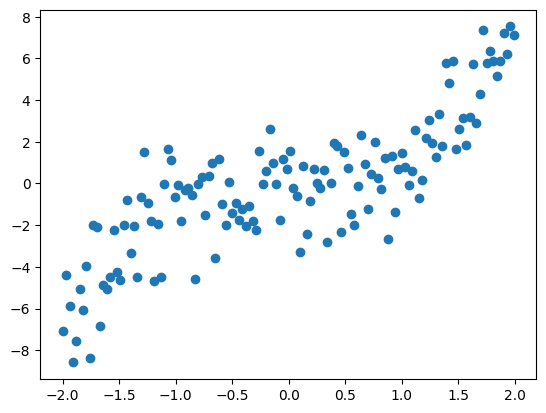

In [74]:
rng = np.random.default_rng(seed = 102)
Xnew = np.arange(-2, 2, 0.03)
ynew = Xnew**3 + rng.normal(0, 1.5, Xnew.shape[0])
X_test = np.column_stack((np.ones(Xnew.shape[0]), Xnew.reshape(-1, 1))).T
y_test = ynew.reshape(-1, 1)
plt.scatter(Xnew,ynew)

## Question 19

Find the loss for the test data points. Consider the loss to be defined as

$$ \sqrt{\dfrac{1}{n}\sum\limits_{i=1}^{n} (y_i- \hat{y}_i)^2}
$$

Where $\hat{y}_i$ is the prediction for $i^{th}$ data point.



In [75]:
## Enter your solution here